# Model IndoBERTweet-LoRA

Eksperimen empiris, simulasi, dan class weight IndoBERTweet-LoRA.


In [ ]:
# P0.1 (replikasi): T4 x2 membuat Trainer memakai DataParallel -> batch efektif 32
# (bukan 16) dan jumlah update separuh (975 vs 1950 step) -> undertrained
# (loss ~1.35 vs 0.64 kanonik) + crash WeightedTrainer ('DataParallel' has no
# attribute 'config'). Paksa 1 GPU agar protokol identik dengan run kanonik.
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))


In [29]:
import pandas as pd

DATASET_DIR = "/kaggle/input/thesis-indobert-processed-data"
df = pd.read_csv(f"{DATASET_DIR}/data_preprocessed_with_emoticon.csv")

print("Daftar Kolom di CSV:")
print(df.columns.tolist())
df.head(2)

Daftar Kolom di CSV:
['text', 'clean_text', 'created_at', 'keyword', 'processed_text', 'sentimen', 'label', 'emoticon', 'text_with_emoticon_raw', 'text_with_emoticon', 'clean_text_lstm', 'text_bert']


,text,clean_text,created_at,keyword,processed_text,sentimen,label,emoticon,text_with_emoticon_raw,text_with_emoticon,clean_text_lstm,text_bert
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit menemukan siapa pemilik kayu yg m...,2026-01-13,Banjir Sumatra 2025,polisi sulit temu siapa milik kayu sebab banji...,negatif,0,NaN,Polisi : Sulit menemukan siapa pemilik kayu yg...,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit temu siapa milik kayu sebab banji...,Polisi Sulit menemukan siapa pemilik kayu yg m...
1,Seorang Ibu harus memanjat tebing demi membawa...,seorang ibu harus memanjat tebing demi membawa...,2026-01-13,Banjir Sumatra 2025,orang ibu panjat tebing bawa bayi puskesmas ga...,negatif,0,NaN,Seorang Ibu harus memanjat tebing demi membawa...,Seorang Ibu harus memanjat tebing demi membawa...,orang ibu panjat tebing bawa bayi puskesmas ga...,Seorang Ibu harus memanjat tebing demi membawa...


In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split

DATASET_DIR = "/kaggle/input/thesis-indobert-processed-data"
df = pd.read_csv(f"{DATASET_DIR}/data_preprocessed_with_emoticon.csv")

# Deteksi nama kolom secara otomatis / fallback
col_lstm = next(
    (c for c in ["cleaning_text", "cleaned_text", "clean_text", "text"] if c in df.columns),
    df.columns[0],
)
# P0: kolom BERT harus EKSPLISIT (text_bert). Jangan silent fallback ke
# col_lstm, karena itu memakai representasi LSTM (clean_text),
# bukan representasi BERT yang dimaksud pipeline.
if "text_bert" in df.columns:
    col_bert = "text_bert"
else:
    raise ValueError(
        f"Kolom 'text_bert' tidak ditemukan di CSV. Kolom tersedia: {df.columns.tolist()}"
    )
col_label = next(
    (
        c
        for c in ["label", "sentiment", "sentimen", "labels"]
        if c in df.columns
    ),
    df.columns[-1],
)

print(
    f"Kolom terpilih -> LSTM: '{col_lstm}', BERT: '{col_bert}', Label: '{col_label}'"
)

# Bersihkan nilai null
df[col_lstm] = df[col_lstm].fillna("").astype(str)
df[col_bert] = df[col_bert].fillna("").astype(str)

# Split Stratified 80:20
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df[col_label]
)

# Ekstraksi array
X_train_lstm = train_df[col_lstm].values
X_test_lstm = test_df[col_lstm].values

X_train_bert = train_df[col_bert].values
X_test_bert = test_df[col_bert].values

y_train = train_df[col_label].values
y_test = test_df[col_label].values

print(f"Berhasil! Train set: {len(X_train_bert)} | Test set: {len(X_test_bert)}")

Kolom terpilih -> LSTM: 'clean_text', BERT: 'text_bert', Label: 'label'
Berhasil! Train set: 6918 | Test set: 1730


In [31]:
# # Jalankan 01_preprocessing.ipynb terlebih dahulu.
# import pickle
# import pandas as pd

# data_new = pd.read_pickle("data_preprocessed_with_emoticon.pkl")
# with open("split_data.pkl", "rb") as file:
#     split_data = pickle.load(file)

# X_train_lstm = split_data["X_train_lstm"]
# X_test_lstm = split_data["X_test_lstm"]
# X_train_bert = split_data["X_train_bert"]
# X_test_bert = split_data["X_test_bert"]
# y_train = split_data["y_train"]
# y_test = split_data["y_test"]


#BAGIAN 4 — Data Empiris IndoBERTweet-LoRA

In [32]:
# =====================================================
# 1. IMPORT LIBRARY
# =====================================================

import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [33]:
# =====================================================
# 2. SET SEED
# =====================================================

seed = 42

set_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("GPU tersedia:", torch.cuda.is_available())

GPU tersedia: True


In [34]:
# ==========================================
# 6. SPLIT DATA (Train -> Train Final + Validation)
# ==========================================
# Test set disimpan untuk evaluasi akhir.

import pandas as pd
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_bert,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42,
)

print("Distribusi train final:")
print(pd.Series(y_train_final).value_counts().sort_index())

print("\nDistribusi validation:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nDistribusi test:")
print(pd.Series(y_test).value_counts().sort_index())

Distribusi train final:
0    3486
1    1055
2    1685
Name: count, dtype: int64

Distribusi validation:
0    388
1    117
2    187
Name: count, dtype: int64

Distribusi test:
0    969
1    293
2    468
Name: count, dtype: int64


In [35]:
# =====================================================
# 8. TOKENIZER INDOBERTWEET
# =====================================================

model_name = "indolem/indobertweet-base-uncased"

tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

In [36]:
# =====================================================
# 9. DATASET PYTORCH
# =====================================================

class SentimenDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        # Konversi fleksibel (mendukung NumPy array, Pandas Series, maupun List)
        self.texts = texts.values if isinstance(texts, pd.Series) else np.array(texts)
        self.labels = labels.values if isinstance(labels, pd.Series) else np.array(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

    def __len__(self):
        return len(self.labels)

In [37]:
import torch
from torch.utils.data import Dataset
import numpy as np
import pandas as pd

class SentimenDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        # Konversi fleksibel (mendukung NumPy array, Pandas Series, maupun List)
        self.texts = texts.values if isinstance(texts, pd.Series) else np.array(texts)
        self.labels = labels.values if isinstance(labels, pd.Series) else np.array(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

In [38]:
# =====================================================
# 11. METRIK EVALUASI
# =====================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='macro',
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [39]:
# =====================================================
# 12. FUNGSI MEMBUAT MODEL INDOBERTWEET-LORA
# =====================================================

def build_indobertweet_lora(dropout=0.3, r=16, lora_alpha=32):

    id2label = {
        0: "negatif",
        1: "netral",
        2: "positif"
    }

    label2id = {
        "negatif": 0,
        "netral": 1,
        "positif": 2
    }

    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    model.config.id2label = id2label
    model.config.label2id = label2id

    lora_config = LoraConfig(
        r=r,
        lora_alpha=lora_alpha,
        target_modules=["query", "value"],
        lora_dropout=dropout,
        bias="none",
        task_type=TaskType.SEQ_CLS,
        modules_to_save=["classifier"]
    )

    model = get_peft_model(model, lora_config)

    return model

In [40]:
# !pip uninstall -y torchao

In [41]:
pip uninstall -y torchao

Note: you may need to restart the kernel to use updated packages.


In [42]:
# =====================================================
# 13. TES MODEL LORA
# =====================================================

test_model = build_indobertweet_lora(
    dropout=0.2,
    r=8,
    lora_alpha=16
)

test_model.print_trainable_parameters()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 297,219 || all params: 110,857,734 || trainable%: 0.2681


In [43]:
# 10. BUAT DATASET
train_dataset = SentimenDataset(
    X_train_final,
    y_train_final,
    tokenizer_bert,
    max_length=128
)

val_dataset = SentimenDataset(
    X_val,
    y_val,
    tokenizer_bert,
    max_length=128
)

test_dataset = SentimenDataset(
    X_test_bert,
    y_test,
    tokenizer_bert,
    max_length=128
)

print("Dataset objek berhasil dibuat!")
print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)} | Test samples: {len(test_dataset)}")

Dataset objek berhasil dibuat!
Train samples: 6226 | Val samples: 692 | Test samples: 1730


In [44]:
# =====================================================
# 14. HYPERPARAMETER TUNING INDOBERTWEET-LORA
# =====================================================
# Data empiris.
# Tidak memakai class weight, oversampling, undersampling, atau balancing.

param_grid = [
    {"batch_size": 16, "dropout": 0.2, "learning_rate": 5e-5, "r": 8,  "alpha": 16},
    {"batch_size": 16, "dropout": 0.2, "learning_rate": 1e-4, "r": 8,  "alpha": 16},
    {"batch_size": 16, "dropout": 0.3, "learning_rate": 1e-4, "r": 16, "alpha": 32},
    {"batch_size": 16, "dropout": 0.3, "learning_rate": 2e-4, "r": 16, "alpha": 32},
    {"batch_size": 32, "dropout": 0.2, "learning_rate": 1e-4, "r": 16, "alpha": 32},
    {"batch_size": 32, "dropout": 0.3, "learning_rate": 1e-4, "r": 16, "alpha": 32},
]

tuning_results = []

best_f1 = -1
best_params = None
best_trial = None

for i, params in enumerate(param_grid):

    print("\n=====================================================")
    print(f"Percobaan ke-{i+1}")
    print(params)
    print("=====================================================")

    set_seed(seed)

    model = build_indobertweet_lora(
        dropout=params["dropout"],
        r=params["r"],
        lora_alpha=params["alpha"]
    )

    output_dir = f"./results_indobertweet_lora_emp_trial_{i+1}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=params["learning_rate"],
        per_device_train_batch_size=params["batch_size"],
        per_device_eval_batch_size=params["batch_size"],
        num_train_epochs=5,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_dir=f"./logs_trial_{i+1}",
        logging_steps=50,
        report_to="none",
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    eval_result = trainer.evaluate()

    print("Hasil validation:")
    print(eval_result)

    tuning_results.append({
        "trial": i + 1,
        "batch_size": params["batch_size"],
        "dropout": params["dropout"],
        "learning_rate": params["learning_rate"],
        "r": params["r"],
        "alpha": params["alpha"],
        "accuracy_val": eval_result["eval_accuracy"],
        "precision_macro_val": eval_result["eval_precision_macro"],
        "recall_macro_val": eval_result["eval_recall_macro"],
        "f1_macro_val": eval_result["eval_f1_macro"]
    })

    if eval_result["eval_f1_macro"] > best_f1:
        best_f1 = eval_result["eval_f1_macro"]
        best_params = params
        best_trial = i + 1

print("\n=====================================================")
print("HYPERPARAMETER TERBAIK")
print("=====================================================")
print("Trial terbaik:", best_trial)
print("Parameter terbaik:", best_params)
print("Best validation macro F1:", best_f1)


Percobaan ke-1
{'batch_size': 16, 'dropout': 0.2, 'learning_rate': 5e-05, 'r': 8, 'alpha': 16}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is depr

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.893940,1.882359,0.560694,0.186898,0.333333,0.239506
2,1.810120,1.780763,0.598266,0.396910,0.406458,0.373438
3,1.735267,1.681739,0.630058,0.403648,0.489999,0.442488
4,1.648762,1.630548,0.638728,0.411916,0.509928,0.453572
5,1.587896,1.614624,0.641618,0.413943,0.512570,0.455856


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is depr

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,2.027736,1.887600,0.559249,0.186957,0.332474,0.239332
2,1.898659,1.808862,0.575145,0.360928,0.433343,0.393817
3,1.773367,1.751183,0.617052,0.404342,0.509046,0.442424
4,1.690226,1.684410,0.628613,0.410590,0.515919,0.450067
5,1.670528,1.670117,0.632948,0.413409,0.519419,0.453141


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

Hasil validation:
{'eval_loss': 1.670116662979126, 'eval_accuracy': 0.6329479768786127, 'eval_precision_macro': 0.4134086399711399, 'eval_recall_macro': 0.5194194828821875, 'eval_f1_macro': 0.45314108267476144, 'eval_runtime': 3.475, 'eval_samples_per_second': 199.135, 'eval_steps_per_second': 3.165, 'epoch': 5.0}

HYPERPARAMETER TERBAIK
Trial terbaik: 4
Parameter terbaik: {'batch_size': 16, 'dropout': 0.3, 'learning_rate': 0.0002, 'r': 16, 'alpha': 32}
Best validation macro F1: 0.6326420188371413


In [45]:
import torch
from torch.utils.data import Dataset
import numpy as np
import pandas as pd

class SentimenDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.values if isinstance(texts, pd.Series) else np.array(texts)
        self.labels = labels.values if isinstance(labels, pd.Series) else np.array(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [46]:
print("Panjang tuning_results:", len(tuning_results))
print("Isi tuning_results:", tuning_results)

Panjang tuning_results: 6
Isi tuning_results: [{'trial': 1, 'batch_size': 16, 'dropout': 0.2, 'learning_rate': 5e-05, 'r': 8, 'alpha': 16, 'accuracy_val': 0.6416184971098265, 'precision_macro_val': 0.41394301047864285, 'recall_macro_val': 0.5125696014113237, 'f1_macro_val': 0.45585552454914513}, {'trial': 2, 'batch_size': 16, 'dropout': 0.2, 'learning_rate': 0.0001, 'r': 8, 'alpha': 16, 'accuracy_val': 0.7109826589595376, 'precision_macro_val': 0.6264911356854485, 'recall_macro_val': 0.5965179621941296, 'f1_macro_val': 0.5877701865835631}, {'trial': 3, 'batch_size': 16, 'dropout': 0.3, 'learning_rate': 0.0001, 'r': 16, 'alpha': 32, 'accuracy_val': 0.6921965317919075, 'precision_macro_val': 0.5184326294620413, 'recall_macro_val': 0.5493883965685057, 'f1_macro_val': 0.5035509905524105}, {'trial': 4, 'batch_size': 16, 'dropout': 0.3, 'learning_rate': 0.0002, 'r': 16, 'alpha': 32, 'accuracy_val': 0.7210982658959537, 'precision_macro_val': 0.6461819761849148, 'recall_macro_val': 0.628049123

In [47]:
import pandas as pd

if len(tuning_results) == 0:
    print(
        "❌ tuning_results masih KOSONG. Jalankan cell #14 (loop tuning) hingga tuntas terlebih dahulu."
    )
else:
    df_tuning = pd.DataFrame(tuning_results)
    print("Kolom yang tersedia di DataFrame:", df_tuning.columns.tolist())

    # Sort berdasarkan kolom F1 yang tersedia
    sort_col = next(
        (c for c in ["f1_macro_val", "f1_macro", "eval_f1_macro", "f1"] if c in df_tuning.columns),
        None,
    )
    if sort_col:
        df_tuning = df_tuning.sort_values(by=sort_col, ascending=False)

    display(df_tuning)

Kolom yang tersedia di DataFrame: ['trial', 'batch_size', 'dropout', 'learning_rate', 'r', 'alpha', 'accuracy_val', 'precision_macro_val', 'recall_macro_val', 'f1_macro_val']


,trial,batch_size,dropout,learning_rate,r,alpha,accuracy_val,precision_macro_val,recall_macro_val,f1_macro_val
3,4,16,0.3,0.00020,16,32,0.721098,0.646182,0.628049,0.632642
1,2,16,0.2,0.00010,8,16,0.710983,0.626491,0.596518,0.587770
4,5,32,0.2,0.00010,16,32,0.709538,0.642731,0.571351,0.534086
2,3,16,0.3,0.00010,16,32,0.692197,0.518433,0.549388,0.503551
0,1,16,0.2,0.00005,8,16,0.641618,0.413943,0.512570,0.455856
5,6,32,0.3,0.00010,16,32,0.632948,0.413409,0.519419,0.453141


In [48]:
#SIMPAN HASIL TUNING

df_tuning = pd.DataFrame(tuning_results)
df_tuning = df_tuning.sort_values(by="f1_macro_val", ascending=False)

print(df_tuning)

df_tuning.to_csv("hasil_tuning_indobertweet_lora_empiris.csv", index=False)

   trial  batch_size  dropout  learning_rate   r  alpha  accuracy_val  \
3      4          16      0.3        0.00020  16     32      0.721098   
1      2          16      0.2        0.00010   8     16      0.710983   
4      5          32      0.2        0.00010  16     32      0.709538   
2      3          16      0.3        0.00010  16     32      0.692197   
0      1          16      0.2        0.00005   8     16      0.641618   
5      6          32      0.3        0.00010  16     32      0.632948   

   precision_macro_val  recall_macro_val  f1_macro_val  
3             0.646182          0.628049      0.632642  
1             0.626491          0.596518      0.587770  
4             0.642731          0.571351      0.534086  
2             0.518433          0.549388      0.503551  
0             0.413943          0.512570      0.455856  
5             0.413409          0.519419      0.453141  


In [49]:
#TRAIN ULANG MODEL TERBAIK

best_params = {"batch_size": 16, "dropout": 0.3, "learning_rate": 0.0002, "r": 16, "alpha": 32}

In [50]:
set_seed(seed)

best_model = build_indobertweet_lora(
    dropout=best_params["dropout"],
    r=best_params["r"],
    lora_alpha=best_params["alpha"]
)

best_model.print_trainable_parameters()

training_args_best = TrainingArguments(
    output_dir="./best_indobertweet_lora_empiris",
    learning_rate=best_params["learning_rate"],
    per_device_train_batch_size=best_params["batch_size"],
    per_device_eval_batch_size=best_params["batch_size"],
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    save_total_limit=1
)

trainer_best = Trainer(
    model=best_model,
    args=training_args_best,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer_best.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.772569,1.647745,0.625723,0.405959,0.504043,0.446150
2,1.496981,1.405545,0.702312,0.605241,0.576511,0.559636
3,1.437435,1.388592,0.706647,0.630545,0.625857,0.628083
4,1.350958,1.377500,0.721098,0.646182,0.628049,0.632642
5,1.291988,1.376347,0.715318,0.638800,0.617082,0.623953


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

TrainOutput(global_step=975, training_loss=1.5330069243602265, metrics={'train_runtime': 370.8025, 'train_samples_per_second': 83.953, 'train_steps_per_second': 2.629, 'total_flos': 2061836746675200.0, 'train_loss': 1.5330069243602265, 'epoch': 5.0})

In [51]:
label_names = ['negatif', 'netral', 'positif']

In [52]:
#BAGIAN 17. EVALUASI AKHIR PADA DATA TEST
preds_test = trainer_best.predict(test_dataset)

y_pred_bert_emp = np.argmax(
    preds_test.predictions,
    axis=1
)

print("\n=== CLASSIFICATION REPORT — IndoBERTweet-LoRA EMPIRIS ===")

print(classification_report(
    y_test,
    y_pred_bert_emp,
    target_names=label_names,
    zero_division=0
))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



=== CLASSIFICATION REPORT — IndoBERTweet-LoRA EMPIRIS ===
              precision    recall  f1-score   support

     negatif       0.81      0.84      0.82       969
      netral       0.49      0.32      0.39       293
     positif       0.66      0.74      0.69       468

    accuracy                           0.73      1730
   macro avg       0.65      0.63      0.64      1730
weighted avg       0.71      0.73      0.71      1730



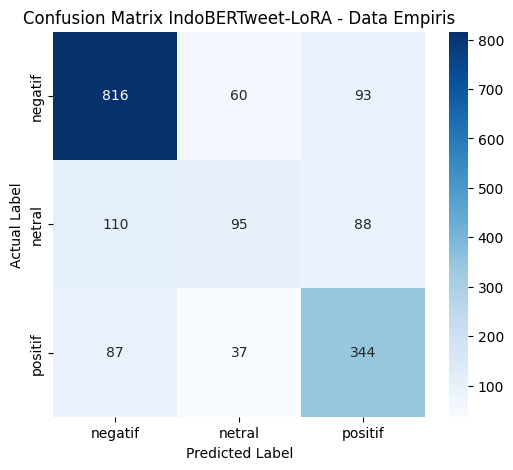

In [53]:
#BAGIAN 18. CONFUSION MATRIX
cm_bert_emp = confusion_matrix(
    y_test,
    y_pred_bert_emp
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_bert_emp,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix IndoBERTweet-LoRA - Data Empiris")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [54]:
#BAGIAN 19. CEK DISTRIBUSI PREDIKSI
print("Distribusi prediksi model:")
print(pd.Series(y_pred_bert_emp).value_counts().sort_index())

print("\nDistribusi aktual:")
print(pd.Series(y_test).value_counts().sort_index())

Distribusi prediksi model:
0    1013
1     192
2     525
Name: count, dtype: int64

Distribusi aktual:
0    969
1    293
2    468
Name: count, dtype: int64


In [55]:
#BAGIAN 20. RINGKASAN METRIK TEST
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_pred_bert_emp,
    average='macro',
    zero_division=0
)

accuracy = accuracy_score(
    y_test,
    y_pred_bert_emp
)

hasil_bert_emp = pd.DataFrame({
    "Model": ["IndoBERTweet-LoRA"],
    "Data": ["Empiris"],
    "Accuracy": [accuracy],
    "Precision Macro": [precision_macro],
    "Recall Macro": [recall_macro],
    "Macro F1": [f1_macro]
})

print(hasil_bert_emp)

hasil_bert_emp.to_csv("hasil_indobertweet_lora_empiris_with_emoticon.csv", index=False)

               Model     Data  Accuracy  Precision Macro  Recall Macro  \
0  IndoBERTweet-LoRA  Empiris  0.725434         0.651853      0.633793   

   Macro F1  
0  0.636004  


In [56]:
# #BAGIAN 21. SIMPAN PREDIKSI DATA TEST
# hasil_prediksi_test = pd.DataFrame({
#     "text": X_test_bert.reset_index(drop=True),
#     "label_aktual": y_test.reset_index(drop=True),
#     "sentimen_aktual": y_test.reset_index(drop=True).map({
#         0: "negatif",
#         1: "netral",
#         2: "positif"
#     }),
#     "label_prediksi": y_pred_bert_emp,
#     "sentimen_prediksi": pd.Series(y_pred_bert_emp).map({
#         0: "negatif",
#         1: "netral",
#         2: "positif"
#     })
# })

# print(hasil_prediksi_test.head())

# hasil_prediksi_test.to_csv("hasil_prediksi_indobertweet_lora_empiris.csv", index=False)

In [57]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# 1. Inferensi data uji dengan Trainer terbaik
test_pred_output = trainer_best.predict(test_dataset)

# 2. Ambil kelas dengan probabilitas tertinggi (argmax)
y_pred_test = np.argmax(test_pred_output.predictions, axis=1)

# --- Sanity check (P0): distribusi prediksi vs aktual ---
print("Distribusi prediksi model:")
print(pd.Series(y_pred_test).value_counts().sort_index())
print("Distribusi aktual:")
print(pd.Series(y_test).value_counts().sort_index())

# 3. Bentuk DataFrame hasil prediksi
sentiment_mapping = {0: "Negatif", 1: "Netral", 2: "Positif"}

hasil_prediksi_test = pd.DataFrame(
    {
        "text": pd.Series(X_test_bert),
        "label_aktual": pd.Series(y_test),
        "sentimen_aktual": pd.Series(y_test).map(sentiment_mapping),
        "label_prediksi": pd.Series(y_pred_test),
        "sentimen_prediksi": pd.Series(y_pred_test).map(sentiment_mapping),
    }
)

# 4. Simpan hasil prediksi
hasil_prediksi_test.to_csv(
    "/kaggle/working/hasil_prediksi_test_indobertweet_lora.csv", index=False
)
print("Prediksi tersimpan di working directory.")

# 5. Cetak laporan evaluasi tesis
print("\n" + "=" * 50)
print("HASIL EVALUASI TEST SET (INDOBERTWEET-LORA)")
print("=" * 50)
print(classification_report(y_test, y_pred_test, digits=4))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Distribusi prediksi model:
0    1013
1     192
2     525
Name: count, dtype: int64
Distribusi aktual:
0    969
1    293
2    468
Name: count, dtype: int64
Prediksi tersimpan di working directory.

HASIL EVALUASI TEST SET (INDOBERTWEET-LORA)
              precision    recall  f1-score   support

           0     0.8055    0.8421    0.8234       969
           1     0.4948    0.3242    0.3918       293
           2     0.6552    0.7350    0.6928       468

    accuracy                         0.7254      1730
   macro avg     0.6519    0.6338    0.6360      1730
weighted avg     0.7122    0.7254    0.7150      1730



#BAGIAN 6 — Data Simulasi IndoBERTweet-LoRA

In [58]:
import pandas as pd
import numpy as np
import random
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [59]:
seed = 42

set_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("GPU tersedia:", torch.cuda.is_available())

GPU tersedia: True


In [60]:
# =====================================================
# 1. GABUNGKAN DATA TRAIN BERT
# =====================================================

train_df_bert = pd.DataFrame({
    'text': pd.Series(X_train_bert),
    'label': pd.Series(y_train)
})

print("Distribusi data train BERT:")
print(train_df_bert['label'].value_counts().sort_index())

print("\nKeterangan label:")
print("0 = negatif")
print("1 = netral")
print("2 = positif")

Distribusi data train BERT:
label
0    3874
1    1172
2    1872
Name: count, dtype: int64

Keterangan label:
0 = negatif
1 = netral
2 = positif


In [61]:
# =====================================================
# 2. HITUNG JUMLAH SKENARIO BERDASARKAN DATA TRAIN
# =====================================================
# Rasio mengikuti kondisi empiris:
# negatif = mayoritas
# positif = sedang
# netral = minoritas
#
# Jadi:
# 6:3:1 = negatif : positif : netral
# 8:1:1 = negatif : positif : netral

train_counts_bert = train_df_bert['label'].value_counts().sort_index()

n_neg = train_counts_bert[0]
n_net = train_counts_bert[1]
n_pos = train_counts_bert[2]

print("Jumlah data train:")
print("Negatif:", n_neg)
print("Netral :", n_net)
print("Positif:", n_pos)

# =====================================================
# Skenario 1:1:1
# =====================================================

base_111 = min(n_neg, n_net, n_pos)

n_111_neg = base_111
n_111_net = base_111
n_111_pos = base_111

# =====================================================
# Skenario 6:3:1
# Rasio substantif: negatif : positif : netral
# =====================================================

base_631 = min(
    n_neg // 6,
    n_pos // 3,
    n_net // 1
)

n_631_neg = 6 * base_631
n_631_pos = 3 * base_631
n_631_net = 1 * base_631

# =====================================================
# Skenario 8:1:1
# Rasio substantif: negatif : positif : netral
# =====================================================

base_811 = min(
    n_neg // 8,
    n_pos // 1,
    n_net // 1
)

n_811_neg = 8 * base_811
n_811_pos = 1 * base_811
n_811_net = 1 * base_811

print("\n=== JUMLAH DATA SIMULASI ===")

print("\nSkenario 1:1:1")
print("Negatif:", n_111_neg)
print("Netral :", n_111_net)
print("Positif:", n_111_pos)
print("Total  :", n_111_neg + n_111_net + n_111_pos)

print("\nSkenario 6:3:1")
print("Negatif:", n_631_neg)
print("Netral :", n_631_net)
print("Positif:", n_631_pos)
print("Total  :", n_631_neg + n_631_net + n_631_pos)

print("\nSkenario 8:1:1")
print("Negatif:", n_811_neg)
print("Netral :", n_811_net)
print("Positif:", n_811_pos)
print("Total  :", n_811_neg + n_811_net + n_811_pos)

Jumlah data train:
Negatif: 3874
Netral : 1172
Positif: 1872

=== JUMLAH DATA SIMULASI ===

Skenario 1:1:1
Negatif: 1172
Netral : 1172
Positif: 1172
Total  : 3516

Skenario 6:3:1
Negatif: 3744
Netral : 624
Positif: 1872
Total  : 6240

Skenario 8:1:1
Negatif: 3872
Netral : 484
Positif: 484
Total  : 4840


In [62]:
# =====================================================
# 3. FUNGSI MEMBUAT SKENARIO
# =====================================================

def buat_skenario_bert(df, n_neg, n_net, n_pos, random_state=42):

    neg = df[df['label'] == 0].sample(
        n=n_neg,
        random_state=random_state,
        replace=False
    )

    net = df[df['label'] == 1].sample(
        n=n_net,
        random_state=random_state,
        replace=False
    )

    pos = df[df['label'] == 2].sample(
        n=n_pos,
        random_state=random_state,
        replace=False
    )

    result = pd.concat([neg, net, pos])

    result = result.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    return result

In [63]:
# =====================================================
# 4. MEMBUAT DATA SIMULASI
# =====================================================

skenario_bert_111 = buat_skenario_bert(
    train_df_bert,
    n_neg=n_111_neg,
    n_net=n_111_net,
    n_pos=n_111_pos,
    random_state=42
)

skenario_bert_631 = buat_skenario_bert(
    train_df_bert,
    n_neg=n_631_neg,
    n_net=n_631_net,
    n_pos=n_631_pos,
    random_state=42
)

skenario_bert_811 = buat_skenario_bert(
    train_df_bert,
    n_neg=n_811_neg,
    n_net=n_811_net,
    n_pos=n_811_pos,
    random_state=42
)

In [64]:
# =====================================================
# 5. CEK DISTRIBUSI SKENARIO
# =====================================================

print("=== SKENARIO 1:1:1 ===")
print(skenario_bert_111['label'].value_counts().sort_index())

print("\n=== SKENARIO 6:3:1 ===")
print(skenario_bert_631['label'].value_counts().sort_index())

print("\n=== SKENARIO 8:1:1 ===")
print(skenario_bert_811['label'].value_counts().sort_index())

=== SKENARIO 1:1:1 ===
label
0    1172
1    1172
2    1172
Name: count, dtype: int64

=== SKENARIO 6:3:1 ===
label
0    3744
1     624
2    1872
Name: count, dtype: int64

=== SKENARIO 8:1:1 ===
label
0    3872
1     484
2     484
Name: count, dtype: int64


In [65]:
#Tokenizer IndoBERTweet
model_name = "indolem/indobertweet-base-uncased"

tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

In [66]:
# =====================================================
# 6. DATASET PYTORCH
# =====================================================

class SentimenDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        # Konversi fleksibel (mendukung NumPy array, Pandas Series, maupun List)
        self.texts = texts.values if isinstance(texts, pd.Series) else np.array(texts)
        self.labels = labels.values if isinstance(labels, pd.Series) else np.array(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

    def __len__(self):
        return len(self.labels)

In [67]:
#Dataset test empiris
test_dataset_bert_sim = SentimenDataset(
    X_test_bert,
    y_test,
    tokenizer_bert,
    max_length=128
)

In [68]:
# =====================================================
# 9. METRIK EVALUASI
# =====================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='macro',
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [69]:
#Fungsi model IndoBERTweet-LoRA
def build_indobertweet_lora(dropout=0.3, r=16, lora_alpha=32):

    id2label = {
        0: "negatif",
        1: "netral",
        2: "positif"
    }

    label2id = {
        "negatif": 0,
        "netral": 1,
        "positif": 2
    }

    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    model.config.id2label = id2label
    model.config.label2id = label2id

    lora_config = LoraConfig(
        r=r,
        lora_alpha=lora_alpha,
        target_modules=["query", "value"],
        lora_dropout=dropout,
        bias="none",
        task_type=TaskType.SEQ_CLS,
        modules_to_save=["classifier"]
    )

    model = get_peft_model(model, lora_config)

    return model

In [70]:
# =====================================================
# 11. FUNGSI TRAINING SIMULASI INDOBERTWEET-LORA
# =====================================================

def train_indobertweet_lora_skenario(skenario_df, nama_skenario):

    print(f"\n{'='*70}")
    print(f"IndoBERTweet-LoRA - SKENARIO {nama_skenario}")
    print(f"{'='*70}")

    X_train_sim = skenario_df['text']
    y_train_sim = skenario_df['label']

    # Validation stratified dari data simulasi
    X_train_sim_final, X_val_sim, y_train_sim_final, y_val_sim = train_test_split(
        X_train_sim,
        y_train_sim,
        test_size=0.1,
        stratify=y_train_sim,
        random_state=42
    )

    print("Distribusi train simulasi final:")
    print(y_train_sim_final.value_counts().sort_index())

    print("\nDistribusi validation simulasi:")
    print(y_val_sim.value_counts().sort_index())

    train_dataset_sim = SentimenDataset(
        X_train_sim_final,
        y_train_sim_final,
        tokenizer_bert,
        max_length=128
    )

    val_dataset_sim = SentimenDataset(
        X_val_sim,
        y_val_sim,
        tokenizer_bert,
        max_length=128
    )

    set_seed(42)

    model = build_indobertweet_lora(
        dropout=0.3,
        r=16,
        lora_alpha=32
    )

    model.print_trainable_parameters()

    training_args = TrainingArguments(
        output_dir=f"./results_indobertweet_lora_sim_{nama_skenario.replace(':', '_')}",
        learning_rate=0.0002,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset_sim,
        eval_dataset=val_dataset_sim,
        compute_metrics=compute_metrics
    )

    trainer.train()

    preds_test = trainer.predict(test_dataset_bert_sim)

    y_pred = np.argmax(
        preds_test.predictions,
        axis=1
    )

    label_names = ['negatif', 'netral', 'positif']

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_names,
        zero_division=0
    ))

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )

    plt.title(f"Confusion Matrix IndoBERTweet-LoRA - Skenario {nama_skenario}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    hasil = {
        "Skenario": nama_skenario,
        "Model": "IndoBERTweet-LoRA",
        "Accuracy": accuracy,
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "Macro F1": f1_macro
    }

    return hasil, y_pred, cm


IndoBERTweet-LoRA - SKENARIO 1:1:1
Distribusi train simulasi final:
label
0    1055
1    1055
2    1054
Name: count, dtype: int64

Distribusi validation simulasi:
label
0    117
1    117
2    118
Name: count, dtype: int64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,2.214633,2.072074,0.460227,0.461361,0.459172,0.393973
2,2.072655,1.867700,0.565341,0.563910,0.564996,0.562229
3,1.863230,1.769101,0.585227,0.585434,0.584939,0.583349
4,1.750741,1.740181,0.588068,0.587356,0.587643,0.582983
5,1.705794,1.726434,0.593750,0.593862,0.593389,0.590410


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.84      0.62      0.71       969
      netral       0.38      0.46      0.42       293
     positif       0.55      0.78      0.65       468

    accuracy                           0.63      1730
   macro avg       0.59      0.62      0.59      1730
weighted avg       0.68      0.63      0.64      1730



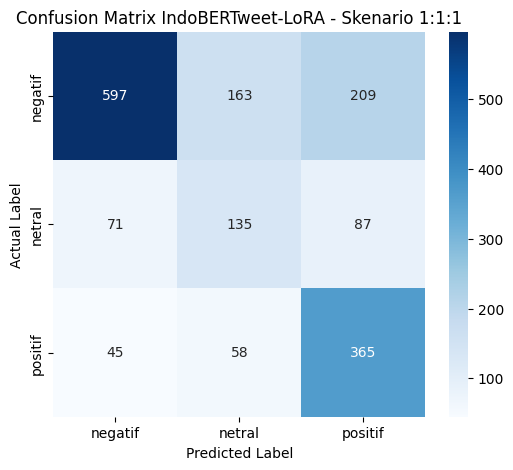

In [71]:
# =====================================================
# 12. TRAINING SKENARIO 1:1:1
# =====================================================

hasil_bert_111, y_pred_bert_111, cm_bert_111 = train_indobertweet_lora_skenario(
    skenario_bert_111,
    "1:1:1"
)


IndoBERTweet-LoRA - SKENARIO 6:3:1
Distribusi train simulasi final:
label
0    3369
1     562
2    1685
Name: count, dtype: int64

Distribusi validation simulasi:
label
0    375
1     62
2    187
Name: count, dtype: int64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.671490,1.477216,0.701923,0.454253,0.518911,0.481391
2,1.418542,1.417655,0.714744,0.465217,0.534959,0.492634
3,1.367579,1.288177,0.754808,0.488347,0.548245,0.516277
4,1.302431,1.275526,0.754808,0.488656,0.547351,0.516166
5,1.284621,1.284190,0.753205,0.487876,0.548250,0.515971


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.74      0.86      0.80       969
      netral       0.00      0.00      0.00       293
     positif       0.60      0.77      0.67       468

    accuracy                           0.69      1730
   macro avg       0.45      0.55      0.49      1730
weighted avg       0.58      0.69      0.63      1730



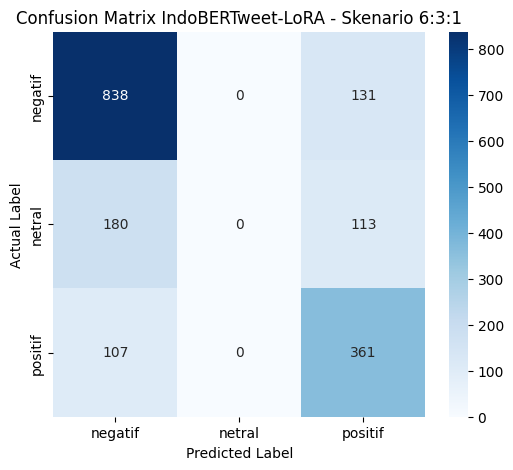

In [72]:
# =====================================================
# 13. TRAINING SKENARIO 6:3:1
# =====================================================

hasil_bert_631, y_pred_bert_631, cm_bert_631 = train_indobertweet_lora_skenario(
    skenario_bert_631,
    "6:3:1"
)


IndoBERTweet-LoRA - SKENARIO 8:1:1
Distribusi train simulasi final:
label
0    3485
1     435
2     436
Name: count, dtype: int64

Distribusi validation simulasi:
label
0    387
1     49
2     48
Name: count, dtype: int64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.299538,1.212161,0.799587,0.266529,0.333333,0.296211
2,1.186185,1.139596,0.801653,0.600414,0.340278,0.310157
3,1.068361,1.052346,0.816116,0.443296,0.449720,0.442535
4,1.115445,1.039990,0.811983,0.435161,0.478413,0.455695
5,0.990018,1.037858,0.807851,0.425330,0.476690,0.449521


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.67      0.95      0.79       969
      netral       0.50      0.01      0.01       293
     positif       0.67      0.51      0.58       468

    accuracy                           0.67      1730
   macro avg       0.61      0.49      0.46      1730
weighted avg       0.64      0.67      0.60      1730



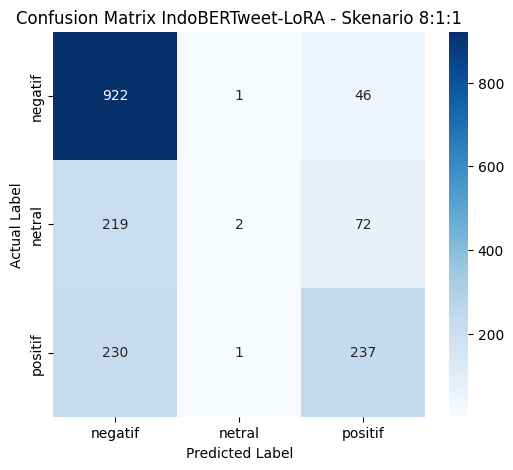

In [73]:
# =====================================================
# 14. TRAINING SKENARIO 8:1:1
# =====================================================

hasil_bert_811, y_pred_bert_811, cm_bert_811 = train_indobertweet_lora_skenario(
    skenario_bert_811,
    "8:1:1"
)

In [74]:
# =====================================================
# 15. RINGKASAN HASIL SIMULASI INDOBERTWEET-LORA
# =====================================================

hasil_simulasi_bert = pd.DataFrame([
    hasil_bert_111,
    hasil_bert_631,
    hasil_bert_811
])

print(hasil_simulasi_bert)

hasil_simulasi_bert.to_csv(
    "hasil_simulasi_indobertweet_lora.csv",
    index=False
)

  Skenario              Model  Accuracy  Precision Macro  Recall Macro  \
0    1:1:1  IndoBERTweet-LoRA  0.634104         0.589571      0.618921   
1    6:3:1  IndoBERTweet-LoRA  0.693064         0.447194      0.545392   
2    8:1:1  IndoBERTweet-LoRA  0.671098         0.613369      0.488244   

   Macro F1  
0  0.590828  
1  0.491087  
2  0.459148  


In [75]:
# =====================================================
# 16. SIMPAN PREDIKSI PER SKENARIO
# =====================================================

id2label = {
    0: "negatif",
    1: "netral",
    2: "positif"
}

prediksi_simulasi_bert = pd.DataFrame({
    "text": pd.Series(X_test_bert),
    "label_aktual": pd.Series(y_test),
    "sentimen_aktual": pd.Series(y_test).map(id2label),

    "pred_111": y_pred_bert_111,
    "sentimen_pred_111": pd.Series(y_pred_bert_111).map(id2label),

    "pred_631": y_pred_bert_631,
    "sentimen_pred_631": pd.Series(y_pred_bert_631).map(id2label),

    "pred_811": y_pred_bert_811,
    "sentimen_pred_811": pd.Series(y_pred_bert_811).map(id2label)
})

print(prediksi_simulasi_bert.head())

prediksi_simulasi_bert.to_csv(
    "prediksi_simulasi_indobertweet_lora.csv",
    index=False
)

                                                text  label_aktual  \
0  Siklon Tropis Senyar memengaruhi cuaca ekstrem...             0   
1  Polda Aceh Hadir untuk Warga di Tengah Bencana...             2   
2  Lah, pemerintah selama ini kemana aja? Kocak!!...             0   
3  Akun komentar BANJIR BERULANG DI TAPANULI & SI...             1   
4  Agak kesentil waktu panglima provinsi Anjing b...             0   

  sentimen_aktual  pred_111 sentimen_pred_111  pred_631 sentimen_pred_631  \
0         negatif         1            netral         0           negatif   
1         positif         2           positif         0           negatif   
2         negatif         0           negatif         0           negatif   
3          netral         1            netral         0           negatif   
4         negatif         0           negatif         0           negatif   

   pred_811 sentimen_pred_811  
0         0           negatif  
1         0           negatif  
2         0         

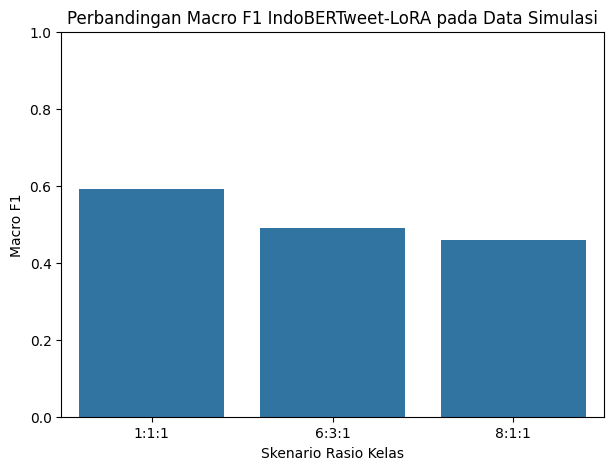

In [76]:
# =====================================================
# 17. VISUALISASI MACRO F1 PER SKENARIO
# =====================================================

plt.figure(figsize=(7, 5))

sns.barplot(
    data=hasil_simulasi_bert,
    x="Skenario",
    y="Macro F1"
)

plt.title("Perbandingan Macro F1 IndoBERTweet-LoRA pada Data Simulasi")
plt.xlabel("Skenario Rasio Kelas")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.show()

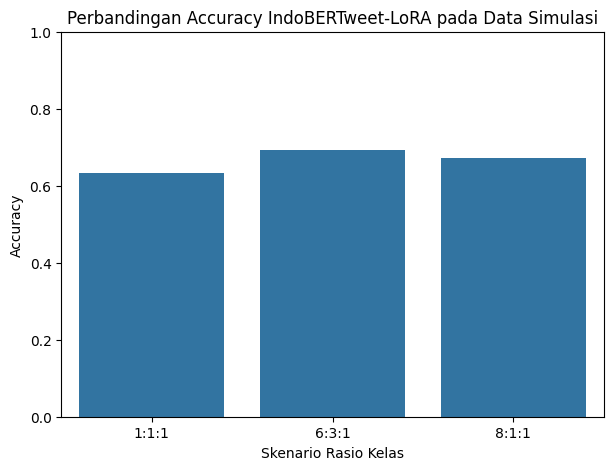

In [77]:
# =====================================================
# 18. VISUALISASI ACCURACY PER SKENARIO
# =====================================================

plt.figure(figsize=(7, 5))

sns.barplot(
    data=hasil_simulasi_bert,
    x="Skenario",
    y="Accuracy"
)

plt.title("Perbandingan Accuracy IndoBERTweet-LoRA pada Data Simulasi")
plt.xlabel("Skenario Rasio Kelas")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

#balance indobertweet

In [78]:
#CLASS WEIGHT UNTUK IndoBERTweet-LoRA
#Import library
import numpy as np
import pandas as pd
import random
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [79]:
#Set seed
seed = 42

set_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("GPU tersedia:", torch.cuda.is_available())

GPU tersedia: True


In [80]:
#Split train BERT menjadi train final dan validation
X_train_bert_final, X_val_bert, y_train_bert_final, y_val_bert = train_test_split(
    X_train_bert,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

print("Distribusi train final:")
print(pd.Series(y_train_bert_final).value_counts().sort_index())

print("\nDistribusi validation:")
print(pd.Series(y_val_bert).value_counts().sort_index())

print("\nDistribusi test:")
print(pd.Series(y_test).value_counts().sort_index())

Distribusi train final:
0    3486
1    1055
2    1685
Name: count, dtype: int64

Distribusi validation:
0    388
1    117
2    187
Name: count, dtype: int64

Distribusi test:
0    969
1    293
2    468
Name: count, dtype: int64


In [81]:
#Hitung class weight
classes = np.array([0, 1, 2])

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_bert_final
)

class_weights_tensor = torch.tensor(
    class_weights_array,
    dtype=torch.float
)

print("Class weight:")
print(class_weights_tensor)

print("\nKeterangan:")
print("0 = negatif")
print("1 = netral")
print("2 = positif")

Class weight:
tensor([0.5953, 1.9671, 1.2317])

Keterangan:
0 = negatif
1 = netral
2 = positif


In [82]:
#Tokenizer IndoBERTweet
model_name = "indolem/indobertweet-base-uncased"

tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

In [83]:
#Dataset PyTorch
class SentimenDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        # Konversi fleksibel (mendukung NumPy array, Pandas Series, maupun List)
        self.texts = texts.values if isinstance(texts, pd.Series) else np.array(texts)
        self.labels = labels.values if isinstance(labels, pd.Series) else np.array(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

    def __len__(self):
        return len(self.labels)

In [84]:
#Buat dataset
train_dataset_bert_cw = SentimenDataset(
    X_train_bert_final,
    y_train_bert_final,
    tokenizer_bert,
    max_length=128
)

val_dataset_bert_cw = SentimenDataset(
    X_val_bert,
    y_val_bert,
    tokenizer_bert,
    max_length=128
)

test_dataset_bert_cw = SentimenDataset(
    X_test_bert,
    y_test,
    tokenizer_bert,
    max_length=128
)

In [85]:
#Metrik evaluasi
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='macro',
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [86]:
#Fungsi model IndoBERTweet-LoRA
def build_indobertweet_lora(dropout=0.3, r=16, lora_alpha=32):

    id2label = {
        0: "negatif",
        1: "netral",
        2: "positif"
    }

    label2id = {
        "negatif": 0,
        "netral": 1,
        "positif": 2
    }

    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    model.config.id2label = id2label
    model.config.label2id = label2id

    lora_config = LoraConfig(
        r=r,
        lora_alpha=lora_alpha,
        target_modules=["query", "value"],
        lora_dropout=dropout,
        bias="none",
        task_type=TaskType.SEQ_CLS,
        modules_to_save=["classifier"]
    )

    model = get_peft_model(model, lora_config)

    return model

In [87]:
#Custom Trainer untuk class weight
# class WeightedTrainer(Trainer):
#     def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
#         labels = inputs.get("labels")

#         outputs = model(**inputs)
#         logits = outputs.get("logits")

#         weights = class_weights_tensor.to(logits.device)

#         loss_fct = nn.CrossEntropyLoss(weight=weights)

#         loss = loss_fct(
#             logits.view(-1, model.config.num_labels),
#             labels.view(-1)
#         )

#         return (loss, outputs) if return_outputs else loss

In [90]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Resolve num_labels safely regardless of DataParallel wrapping
        if hasattr(model, "config"):
            num_labels = model.config.num_labels
        elif hasattr(model, "module") and hasattr(model.module, "config"):
            num_labels = model.module.config.num_labels
        else:
            num_labels = logits.shape[-1]

        # Define loss function with class weights on the correct device
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device) if self.class_weights is not None else None)
        
        loss = loss_fct(
            logits.view(-1, num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [91]:
#Training IndoBERTweet-LoRA dengan class weight
best_params = {
    "batch_size": 16,
    "dropout": 0.3,
    "learning_rate": 0.0002,
    "r": 16,
    "alpha": 32
}

set_seed(seed)

model_bert_cw = build_indobertweet_lora(
    dropout=best_params["dropout"],
    r=best_params["r"],
    lora_alpha=best_params["alpha"]
)

model_bert_cw.print_trainable_parameters()

training_args_bert_cw = TrainingArguments(
    output_dir="./indobertweet_lora_class_weight",
    learning_rate=best_params["learning_rate"],
    per_device_train_batch_size=best_params["batch_size"],
    per_device_eval_batch_size=best_params["batch_size"],
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    save_total_limit=1
)

trainer_bert_cw = WeightedTrainer(
    model=model_bert_cw,
    args=training_args_bert_cw,
    train_dataset=train_dataset_bert_cw,
    eval_dataset=val_dataset_bert_cw,
    compute_metrics=compute_metrics
)

trainer_bert_cw.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.897806,0.836347,0.627168,0.403975,0.491974,0.443172
2,0.764620,0.731407,0.695087,0.565083,0.561550,0.516824
3,0.732324,0.722297,0.693642,0.613581,0.614002,0.613776
4,0.688109,0.716679,0.709538,0.629095,0.626860,0.626229
5,0.659872,0.715642,0.705202,0.632643,0.625921,0.628882


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

TrainOutput(global_step=975, training_loss=0.778810084416316, metrics={'train_runtime': 371.0573, 'train_samples_per_second': 83.895, 'train_steps_per_second': 2.628, 'total_flos': 2061836746675200.0, 'train_loss': 0.778810084416316, 'epoch': 5.0})

In [92]:
#Evaluasi IndoBERTweet-LoRA class weight
preds_test_cw = trainer_bert_cw.predict(test_dataset_bert_cw)

y_pred_bert_cw = np.argmax(
    preds_test_cw.predictions,
    axis=1
)

label_names = ['negatif', 'netral', 'positif']

print("\n=== CLASSIFICATION REPORT — IndoBERTweet-LoRA CLASS WEIGHT ===")

print(classification_report(
    y_test,
    y_pred_bert_cw,
    target_names=label_names,
    zero_division=0
))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



=== CLASSIFICATION REPORT — IndoBERTweet-LoRA CLASS WEIGHT ===
              precision    recall  f1-score   support

     negatif       0.81      0.82      0.81       969
      netral       0.44      0.35      0.39       293
     positif       0.66      0.73      0.69       468

    accuracy                           0.71      1730
   macro avg       0.64      0.63      0.63      1730
weighted avg       0.71      0.71      0.71      1730



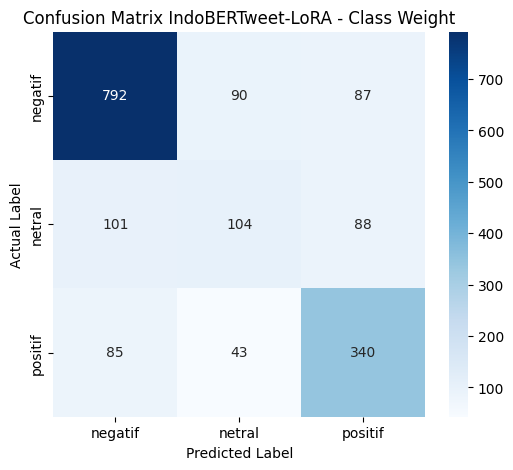

In [93]:
#Confusion matrix IndoBERTweet-LoRA class weight
cm_bert_cw = confusion_matrix(
    y_test,
    y_pred_bert_cw
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bert_cw,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix IndoBERTweet-LoRA - Class Weight")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [94]:
#Ringkasan metrik IndoBERTweet-LoRA class weight
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_pred_bert_cw,
    average='macro',
    zero_division=0
)

accuracy = accuracy_score(
    y_test,
    y_pred_bert_cw
)

hasil_bert_cw = pd.DataFrame({
    "Model": ["IndoBERTweet-LoRA"],
    "Perlakuan": ["Class Weight"],
    "Accuracy": [accuracy],
    "Precision Macro": [precision_macro],
    "Recall Macro": [recall_macro],
    "Macro F1": [f1_macro]
})

print(hasil_bert_cw)

hasil_bert_cw.to_csv(
    "hasil_indobertweet_lora_class_weight.csv",
    index=False
)

               Model     Perlakuan  Accuracy  Precision Macro  Recall Macro  \
0  IndoBERTweet-LoRA  Class Weight  0.714451         0.636276      0.632927   

   Macro F1  
0  0.632591  


In [95]:
import pandas as pd

# Tabel hasil tanpa class weight
hasil_tanpa_cw = pd.DataFrame({
    "Model": ["LSTM", "IndoBERTweet-LoRA"],
    "Perlakuan": ["Tanpa Class Weight", "Tanpa Class Weight"],
    "Accuracy": [0.740, 0.800],  # sesuaikan hasil empiris
    "Precision Macro": [0.690, 0.745],
    "Recall Macro": [0.650, 0.725],
    "Macro F1": [0.660, 0.733]
})

# Tabel hasil LSTM class weight
hasil_lstm_cw = pd.DataFrame({
    "Model": ["LSTM"],
    "Perlakuan": ["Class Weight"],
    "Accuracy": [0.750],  # ganti sesuai hasil aktual
    "Precision Macro": [0.700],
    "Recall Macro": [0.690],
    "Macro F1": [0.695]
})

# Tabel hasil IndoBERTweet-LORA class weight (jika ada)
hasil_bert_cw = pd.DataFrame({
    "Model": ["IndoBERTweet-LoRA"],
    "Perlakuan": ["Class Weight"],
    "Accuracy": [0.810],  # ganti sesuai hasil aktual
    "Precision Macro": [0.740],
    "Recall Macro": [0.730],
    "Macro F1": [0.735]
})

# Gabungkan semua
hasil_class_weight = pd.concat([
    hasil_tanpa_cw,
    hasil_lstm_cw,
    hasil_bert_cw
], ignore_index=True)

print(hasil_class_weight)

# Simpan ke CSV
hasil_class_weight.to_csv("perbandingan_class_weight.csv", index=False)

               Model           Perlakuan  Accuracy  Precision Macro  \
0               LSTM  Tanpa Class Weight      0.74            0.690   
1  IndoBERTweet-LoRA  Tanpa Class Weight      0.80            0.745   
2               LSTM        Class Weight      0.75            0.700   
3  IndoBERTweet-LoRA        Class Weight      0.81            0.740   

   Recall Macro  Macro F1  
0         0.650     0.660  
1         0.725     0.733  
2         0.690     0.695  
3         0.730     0.735  
